In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PetThermoTools as ptt
import Thermobar as pt

In [3]:
import os
import sys
## If using Mac run this cell **twice** 
sys.stdout = open(os.devnull, 'w')
sys.stderr = open(os.devnull, 'w')

In [4]:
# Melt inclusion and groundmass glass data from Mt St Helens (Blundy and Cashman, 2005)
StHelens = pd.read_excel('StHelens.xlsx', sheet_name='1980_WhitePumice')
StHelens = StHelens.fillna(0.0)
StHelens.head()

,sample,Type,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,H2O,Total
0,KCHB-4Aa,A1,68.05,0.33,12.96,2.72,0.12,0.98,1.95,5.60,1.93,4.63,99.26
1,KCHB-7Ab,A1,69.01,0.37,14.07,2.19,0.02,0.36,2.25,5.54,1.85,3.19,99.09
2,KCHB-8Aa,A1,70.19,0.35,14.70,2.52,0.03,0.34,2.24,6.51,1.72,1.83,100.43
3,KCHB-I IR,A1,65.81,0.51,15.03,2.13,0.00,0.37,2.35,5.65,2.44,4.92,99.2
4,KCHB-I IB',A1,69.71,0.21,14.15,2.48,0.00,0.45,2.23,6.39,2.03,2.66,100.29


In [5]:
sat = ptt.saturation_pressure(Model = "MELTSv1.2.0", bulk = StHelens, T_C_init = 1000.0,
                              CO2_init = 0.02, fO2_buffer = "NNO", fO2_offset = 1, timeout=30)

In [6]:
bulk=pd.Series(sat.loc[sat['P_bar']==np.max(sat['P_bar'])].iloc[0]).to_dict()

In [7]:
decom = ptt.isothermal_decompression(Model = "MELTSv1.2.0", bulk = bulk,
                                     T_C = bulk['T_Liq'], P_start_bar = bulk['P_bar'],
                                     P_end_bar = 50.0, dp_bar = 25.0)

In [ ]:
WhitePumice = 2

In [ ]:
decom = ptt.isothermal_decompression(Model = "MELTSv1.2.0", bulk = WhitePumice,
    find_liquidus=True, P_start_bar = 2600.0, P_end_bar = 50.0, dp_bar = 25.0)

In [8]:
decom_s = ptt.isentropic_decompression(Model = "MELTSv1.2.0", bulk = WhitePumice,
                                     T_C = bulk['T_Liq'], P_start_bar = bulk['P_bar'],
                                     P_end_bar = 50.0, dp_bar = 25.0)

In [9]:
Mass_frac = decom['Mass']/100
Vol_frac = (decom['Volume'].T/decom_s['Volume'].sum(axis = 1)).T

In [11]:
import Thermobar as pt
vis = pt.calculate_viscosity_giordano_2008(decom['liquid1'],
    T=decom['All']['T_C'], H2O_Liq=decom['liquid1']['H2O_Liq'])

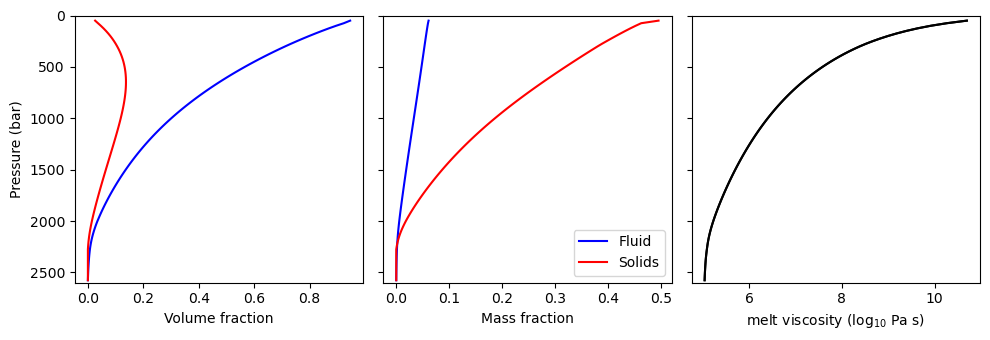

In [13]:
f, a = plt.subplots(1,3, figsize = (10,3.5), sharey=True)
a[0].plot(Vol_frac['fluid1'], decom['All']['P_bar'], '-b')
a[0].plot(Vol_frac.sum(axis = 1) - Vol_frac['fluid1'] - Vol_frac['liquid1'], 
          decom['All']['P_bar'], '-r')
a[0].set_xlabel('Volume fraction')
a[0].set_ylabel('Pressure (bar)')
a[0].set_ylim([2600,0])

a[1].plot(Mass_frac['fluid1'], decom['All']['P_bar'], '-b', label = 'Fluid')
a[1].plot(Mass_frac.sum(axis = 1) - Mass_frac['fluid1'] - Mass_frac['liquid1'], 
          decom['All']['P_bar'], '-r', label = 'Solids')
a[1].set_xlabel('Mass fraction')
a[1].legend()

a[2].plot(vis['logn_melt'], decom['All']['P_bar'], '-k')
a[2].set_xlabel('melt viscosity (log$_{10}$ Pa s)')

f.tight_layout()